## Baseline

In [17]:
import sys

In [18]:
MODEL = "microsoft/Phi-3-mini-4k-instruct"
DEVICE = "cuda:0"
LIMIT = 300

In [3]:
BASE_OUT = f"outputs/phi3mini_hellaswag_limit{LIMIT}_baseline.json"
ABL_OUT  = f"outputs/phi3mini_hellaswag_limit{LIMIT}_SW_ablation.json"
RAND_OUT = f"outputs/phi3mini_hellaswag_limit{LIMIT}_random_ablation.json"

In [4]:
!{sys.executable} evaluate.py \
  --model hf-outlier \
  --model_args pretrained={MODEL},load_in_8bit=False,dtype=bfloat16,device_map=auto,offload_folder=./offload_phi \
  --tasks hellaswag \
  --device {DEVICE} \
  --limit {LIMIT} \
  --output_path {BASE_OUT}

2026-02-27:14:31:32 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-02-27:14:31:41 INFO     [_cli.run:378] Selected Tasks: ['hellaswag']
2026-02-27:14:31:41 WARNING  [evaluator:183] pretrained=microsoft/Phi-3-mini-4k-instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-02-27:14:31:41 INFO     [evaluator:213] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-02-27:14:31:41 INFO     [evaluator:238] Initializing hf-outlier model, with arguments: {'pretrained': 'microsoft/Phi-3-mini-4k-instruct', 'load_in_8bit': False, 'dtype': 'bfloat16', 'device_map': 'auto', 'offload_folder': './offload_phi'}
2026-02-27:14:31:41 INFO     [models.huggingface:161] Using device 'cuda:0'
generation_config.json: 100%|██████

## Superweight ablation

In [6]:
!{sys.executable} evaluate.py \
  --model hf-outlier \
  --model_args pretrained={MODEL},load_in_8bit=False,dtype=bfloat16,device_map=auto,offload_folder=./offload_phi,outlier_method=manual_scaling_SO_0.0 \
  --tasks hellaswag \
  --device {DEVICE} \
  --limit {LIMIT} \
  --output_path {ABL_OUT}

2026-02-27:14:39:25 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-02-27:14:39:30 INFO     [_cli.run:378] Selected Tasks: ['hellaswag']
2026-02-27:14:39:30 WARNING  [evaluator:183] pretrained=microsoft/Phi-3-mini-4k-instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-02-27:14:39:30 INFO     [evaluator:213] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-02-27:14:39:30 INFO     [evaluator:238] Initializing hf-outlier model, with arguments: {'pretrained': 'microsoft/Phi-3-mini-4k-instruct', 'load_in_8bit': False, 'dtype': 'bfloat16', 'device_map': 'auto', 'offload_folder': './offload_phi', 'outlier_method': 'manual_scaling_SO_0.0'}
2026-02-27:14:39:31 INFO     [models.huggingface:161] Using device '

## Random Ablation

In [7]:
!{sys.executable} evaluate.py \
  --model hf-outlier \
  --model_args pretrained={MODEL},load_in_8bit=False,dtype=bfloat16,device_map=auto,offload_folder=./offload_phi,outlier_method=random_ablate_1234 \
  --tasks hellaswag \
  --device {DEVICE} \
  --limit {LIMIT} \
  --output_path {RAND_OUT}

2026-02-27:14:41:50 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-02-27:14:41:55 INFO     [_cli.run:378] Selected Tasks: ['hellaswag']
2026-02-27:14:41:55 WARNING  [evaluator:183] pretrained=microsoft/Phi-3-mini-4k-instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-02-27:14:41:55 INFO     [evaluator:213] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-02-27:14:41:55 INFO     [evaluator:238] Initializing hf-outlier model, with arguments: {'pretrained': 'microsoft/Phi-3-mini-4k-instruct', 'load_in_8bit': False, 'dtype': 'bfloat16', 'device_map': 'auto', 'offload_folder': './offload_phi', 'outlier_method': 'random_ablate_1234'}
2026-02-27:14:41:56 INFO     [models.huggingface:161] Using device 'cud

## Mix Ablate SW + Random

In [15]:
for n in range(0, 7):  # Phi: 0..6
    out = f"outputs/phi3mini_hellaswag_limit{LIMIT}_mix_ablate_{n}.json"
    !{sys.executable} evaluate.py \
      --model hf-outlier \
      --model_args pretrained={MODEL},load_in_8bit=False,dtype=bfloat16,device_map=auto,offload_folder=./offload_phi,outlier_method=mix_ablate_{n}_1234 \
      --tasks hellaswag \
      --device {DEVICE} \
      --limit {LIMIT} \
      --output_path {out}

2026-02-27:15:07:59 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-02-27:15:08:05 INFO     [_cli.run:378] Selected Tasks: ['hellaswag']
2026-02-27:15:08:05 WARNING  [evaluator:183] pretrained=microsoft/Phi-3-mini-4k-instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-02-27:15:08:05 INFO     [evaluator:213] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-02-27:15:08:05 INFO     [evaluator:238] Initializing hf-outlier model, with arguments: {'pretrained': 'microsoft/Phi-3-mini-4k-instruct', 'load_in_8bit': False, 'dtype': 'bfloat16', 'device_map': 'auto', 'offload_folder': './offload_phi', 'outlier_method': 'mix_ablate_0_1234'}
2026-02-27:15:08:05 INFO     [models.huggingface:161] Using device 'cuda

## Analysis

In [20]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

tok = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()

/home/mknell/masters-thesis-llm-inference/LLMSuperWeight/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- modeling_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attenti

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
          (rotary_emb): Phi3RotaryEmbedding()
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLU()
        )
        (input_layernorm): Phi3RMSNorm()
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
        (post_attention_layernorm): Phi3RMSNorm()
      )
    )
    (norm): Phi3RMSNorm()
  )
  (lm_head): Linear(in_features=3072, out_features=3206

You are not running the flash-attention implementation, expect numerical differences.


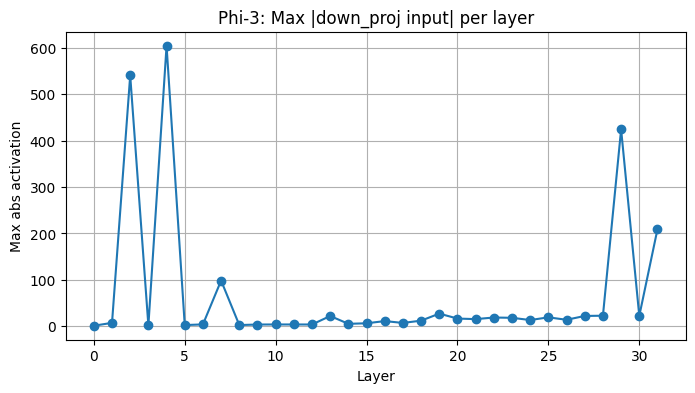

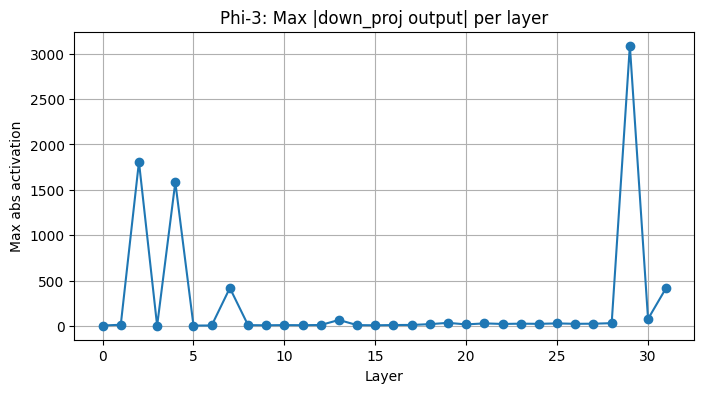

Spike layer: 29
Input channel k: 4800
Output channel j: 525
Candidate SW coordinate: down_proj.weight[j, k] = (525, 4800)
Absolute candidate weight value: 2.765625


In [21]:
import torch
import matplotlib.pyplot as plt

texts = [
    "The quick brown fox jumps over the lazy dog.",
    "In a shocking finding, scientists discovered a herd of unicorns living in a remote valley.",
    "Write a short explanation of why quantization can hurt model accuracy."
]

def get_transformer_layers(model):
    # Phi-3 hat normalerweise model.model.layers
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    raise ValueError("Could not find transformer layers. Inspect model structure with print(model).")

def get_down_proj_module(layer):
    # Für Phi-3 normalerweise mlp.down_proj
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "down_proj"):
        return layer.mlp.down_proj

    # Fallback für andere mögliche Namensgebungen
    if hasattr(layer, "mlp") and hasattr(layer.mlp, "fc2"):
        return layer.mlp.fc2

    raise ValueError("Could not find down projection module in this layer.")

def get_model_device(model):
    # robust bei device_map="auto"
    return next(model.parameters()).device

def collect_max_abs_for_module(module, inputs, outputs, store: dict):
    x = inputs[0].detach()
    y = outputs.detach()

    x_abs = x.abs().reshape(-1, x.shape[-1])   # [B*S, H_in]
    y_abs = y.abs().reshape(-1, y.shape[-1])   # [B*S, H_out]

    x_max = x_abs.max(dim=0).values
    y_max = y_abs.max(dim=0).values

    # Maximum über alle Prompts behalten
    if "in_max" not in store:
        store["in_max"] = x_max
        store["out_max"] = y_max
    else:
        store["in_max"] = torch.maximum(store["in_max"], x_max)
        store["out_max"] = torch.maximum(store["out_max"], y_max)

def layer_downproj_stats(model, tok, layer_idx: int, texts, max_len: int = 128):
    layers = get_transformer_layers(model)
    layer = layers[layer_idx]
    mod = get_down_proj_module(layer)

    store = {}
    hook = mod.register_forward_hook(
        lambda m, inp, out: collect_max_abs_for_module(m, inp, out, store)
    )

    device = get_model_device(model)

    with torch.no_grad():
        for t in texts:
            inp = tok(t, return_tensors="pt", truncation=True, max_length=max_len)
            inp = {k: v.to(device) for k, v in inp.items()}
            _ = model(**inp)

    hook.remove()

    in_peak_val, in_peak_ch = store["in_max"].max(dim=0)
    out_peak_val, out_peak_ch = store["out_max"].max(dim=0)

    return (
        float(in_peak_val.cpu()),
        int(in_peak_ch.cpu()),
        float(out_peak_val.cpu()),
        int(out_peak_ch.cpu()),
    )

# ---- run over all layers ----
layers = get_transformer_layers(model)
L = len(layers)

in_vals, in_chs = [], []
out_vals, out_chs = [], []

for l in range(L):
    in_v, in_c, out_v, out_c = layer_downproj_stats(model, tok, l, texts)
    in_vals.append(in_v)
    in_chs.append(in_c)
    out_vals.append(out_v)
    out_chs.append(out_c)

# ---- plots ----
plt.figure(figsize=(8, 4))
plt.plot(range(L), in_vals, marker="o")
plt.title("Phi-3: Max |down_proj input| per layer")
plt.xlabel("Layer")
plt.ylabel("Max abs activation")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(L), out_vals, marker="o")
plt.title("Phi-3: Max |down_proj output| per layer")
plt.xlabel("Layer")
plt.ylabel("Max abs activation")
plt.grid(True)
plt.show()

# ---- candidate superweight ----
spike_layer = int(max(range(L), key=lambda i: out_vals[i]))
print("Spike layer:", spike_layer)
print("Input channel k:", in_chs[spike_layer])
print("Output channel j:", out_chs[spike_layer])
print("Candidate SW coordinate: down_proj.weight[j, k] =", (out_chs[spike_layer], in_chs[spike_layer]))

# optional: tatsächlichen Gewichtswert anschauen
W = get_down_proj_module(layers[spike_layer]).weight
print("Absolute candidate weight value:", float(W[out_chs[spike_layer], in_chs[spike_layer]].abs().cpu()))